# End-to-End Opinf for multiple initial conditions
## What this notebook can do
- Compute a POD basis for 1+ intial conditions
- Find the operator(s) for $\gamma_n$, $\gamma_c$, and state
- Use learned operator(s) and POD to compute predictions across unseen data

## Memory Management Notes

**Memory-mapped files created in `output_path`:**
- `memmap_Q_train.dat` - Full training snapshots (only during step_1)
- `memmap_Q_test.dat` - Full test snapshots (only during step_1)  
- `memmap_X_recon_full.dat` - Full-space model reconstruction
- `memmap_X_truth_full.dat` - Full-space ground truth reconstruction

**Use cases:**
- **Full run** (`step_1=True, step_2=True`): Computes POD, trains ROM, makes predictions
- **ROM only** (`step_1=False, step_2=True`): Loads existing POD, trains new ROM
- **Predictions only** (`step_1=False, step_2=False`): Loads existing POD and ROM

**Cleanup:** To free disk space after you're done, run:
```python
for name in ["Q_train", "Q_test", "X_recon_full", "X_truth_full"]:
    cleanup_memmap(name)
```

In [1]:
### New best version
# pip install -e . --no-deps  # Install without dependencies first
# pip install -e .            # Then install with pinned dependencies

In [19]:
%matplotlib inline
from opinf_for_hw.data_proc import *
from opinf_for_hw.postproc import *
from opinf_for_hw.utils.helpers import loader
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import h5py
from IPython import display
import xarray as xr
import time
import gc
import os

# General Config
cluster = True
show_animations = False
show_plots = True
ENGINE = "h5netcdf"
plt.rcParams['animation.embed_limit'] = 250
plt.rcParams["image.cmap"] = "bwr" # Other options: seismic

# Control Config
step_1 = False # Compute POD
step_2 = False # Compute ROM

# Memory Config
use_chunked_projection = False  # Set True to project in chunks (lower peak memory)


def bprint(string: str):
    print("\033[1m" + string + "\033[0m")

def get_memmap_path(name):
    """Get path for memory-mapped file."""
    return os.path.join(output_path, f"memmap_{name}.dat")

def cleanup_memmap(name):
    """Remove memory-mapped file if it exists."""
    path = get_memmap_path(name)
    if os.path.exists(path):
        os.remove(path)

if cluster:
    bprint("Using cluster settings")
    from config.cluster import *
else:
    bprint("Using local settings")
    from config.local import *

if r > svd_save:
    bprint("Warning! r value larger than svd_save")

bprint(f"Number of training trajectories/files: {len(training_files)}")
bprint(f"Number of test trajectories/files: {len(test_files)}")

Using cluster settings
Number of training trajectories/files: 1
Number of test trajectories/files: 1


In [3]:
np.__config__.show()

blas_mkl_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/lib/intel64']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl', '/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/include', '/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/lib']
blas_opt_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/lib/intel64']
    define_macros = [('SCIPY_MKL_H', None), ('HAVE_CBLAS', None)]
    include_dirs = ['/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl', '/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/include', '/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/lib']
lapack_mkl_info:
    libraries = ['mkl_rt', 'pthread']
    library_dirs = ['/opt/intel/compilers_and_libraries_2019.5.281/linux/mkl/lib/intel64']
    define_macro

## Step 1: Compute POD basis

### Step 1.1: Load training and test data

In [4]:
def load_and_process_snapshots(file_path, i, dataset_name=""):
    """Helper function to load and process a single snapshot file.
    Returns processed array and its shape info (doesn't append to list).
    """
    print(f"  Loading IC {i+1}: {file_path}")
    fh = xr.open_dataset(file_path, 
                         engine=ENGINE, 
                         phony_dims="sort"
                        )
    
    # Get density and phi as numpy arrays
    density = fh["density"].values
    phi = fh["phi"].values
    fh.close()  # Explicitly close file handle
    
    if i == 0 and show_plots:
        plt.imshow(density[0])
        plt.colorbar()
        plt.show()
        bprint(f"{dataset_name}IC{i} shape: {density.shape}")
    
    # If already 3D (time, y, x), use as-is. If 2D (time, flattened), reshape to 3D
    if density.ndim == 2:
        n_time = density.shape[0]
        grid_size = int(np.sqrt(density.shape[1]))
        density = density.reshape(n_time, grid_size, grid_size)
        phi = phi.reshape(n_time, grid_size, grid_size)
    
    # Stack fields: (time, y, x) -> (field, time, y, x)
    Q_ic = np.stack([density, phi], axis=0)  # Shape: (2, time, y, x)
    del density, phi  # Free memory immediately
    
    # Transpose to (field, y, x, time) before flattening
    Q_ic = Q_ic.transpose(0, 2, 3, 1)  # Shape: (2, 256, 256, time)
    
    # Now reshape: flatten spatial dimensions
    n_field, n_y, n_x, n_time = Q_ic.shape
    Q_ic = Q_ic.reshape(n_field * n_y * n_x, n_time)  # Shape: (131072, time)
    
    print(f"    Shape: {Q_ic.shape}")
    return Q_ic


if step_1:
    bprint("Reading snapshot(s) - Building memory-mapped arrays")
    
    # First pass: determine total sizes
    train_timesteps = []
    test_timesteps = []
    n_spatial = None
    
    for file_path in training_files:
        with xr.open_dataset(file_path, engine=ENGINE, phony_dims="sort") as fh:
            n_time = fh["density"].shape[0]
            if n_spatial is None:
                if fh["density"].ndim == 3:
                    n_spatial = 2 * fh["density"].shape[1] * fh["density"].shape[2]
                else:
                    n_spatial = 2 * fh["density"].shape[1]
            train_timesteps.append(n_time)
    
    for file_path in test_files:
        with xr.open_dataset(file_path, engine=ENGINE, phony_dims="sort") as fh:
            test_timesteps.append(fh["density"].shape[0])
    
    total_train_time = sum(train_timesteps)
    total_test_time = sum(test_timesteps)
    
    bprint(f"Creating memory-mapped arrays: {n_spatial} spatial × {total_train_time} train timesteps")
    
    # Create memory-mapped arrays for Q_train and Q_test
    cleanup_memmap("Q_train")
    cleanup_memmap("Q_test")
    
    Q_train = np.memmap(get_memmap_path("Q_train"), dtype='float64', mode='w+', 
                        shape=(n_spatial, total_train_time))
    Q_test = np.memmap(get_memmap_path("Q_test"), dtype='float64', mode='w+', 
                       shape=(n_spatial, total_test_time))
    
    # Store timestep boundaries for later IC extraction
    train_boundaries = [0] + list(np.cumsum(train_timesteps))
    test_boundaries = [0] + list(np.cumsum(test_timesteps))
    
    # Load training data directly into memmap
    for i, file_path in enumerate(training_files):
        Q_ic = load_and_process_snapshots(file_path, i, dataset_name="")
        start_idx = train_boundaries[i]
        end_idx = train_boundaries[i + 1]
        Q_train[:, start_idx:end_idx] = Q_ic
        
        if i == 0 and show_plots:
            img = Q_ic[:256*256, 0].reshape(256, 256)
            plt.imshow(img)
            plt.colorbar()
            plt.show()
        del Q_ic
        gc.collect()
    
    bprint(f"Combined training data shape: {Q_train.shape}")
    
    # Load test data directly into memmap
    for i, file_path in enumerate(test_files):
        Q_ic = load_and_process_snapshots(file_path, i, dataset_name="Test ")
        start_idx = test_boundaries[i]
        end_idx = test_boundaries[i + 1]
        Q_test[:, start_idx:end_idx] = Q_ic
        del Q_ic
        gc.collect()
    
    bprint(f"Combined test data shape: {Q_test.shape}")
    
    # Save boundaries for IC extraction
    np.savez(output_path + "data_boundaries.npz", 
             train_boundaries=train_boundaries, 
             test_boundaries=test_boundaries,
             n_spatial=n_spatial)
    
else:
    bprint("Skipping data loading (step_1=False, will load POD directly)")

Skipping data loading (step_1=False, will load POD directly)


### Step 1.2: Compute POD

In [5]:
if step_1: 
    # Compute POD basis from combined training data
    bprint("Computing POD basis from all training trajectories...")
    start_time = time.time()

    U, S, _ = np.linalg.svd(Q_train, full_matrices=False)

    elapsed = time.time() - start_time
    print(f"  POD computation completed in {elapsed:.3f} seconds.")
    
    # Save POD data
    POD_file_multi = output_path + "POD_multi_IC.npz"
    np.savez(POD_file_multi, S=S, U=U)
    print(f"  Saved POD basis to {POD_file_multi}")
    print(f"  U shape: {U.shape}, S shape: {S.shape}")
    
    gc.collect()

else:
    # Load previous POD basis
    bprint("Loading POD basis...")
    POD_file_multi = output_path + "POD_multi_IC.npz"
    POD_multi = np.load(POD_file_multi)
    S, U = POD_multi['S'], POD_multi['U']
    del POD_multi
    gc.collect()
    print(f"  Loaded POD basis from {POD_file_multi}")
    print(f"  U shape: {U.shape}, S shape: {S.shape}")

Loading POD basis...
  Loaded POD basis from /work2/10407/anthony50102/frontera/data/sciml_roms_hasegawa_wakatani/POD_multi_IC.npz
  U shape: (131072, 16001), S shape: (16001,)


### Step 1.3: Project train & test

In [6]:
if step_1:
    # Project training data
    bprint("Projecting training data...")
    # Use only the modes we need (truncate U to r modes for projection storage)
    Ur = U[:, :r]
    
    Xhat_train = Q_train.T @ Ur  # Shape: (n_time, r) - much smaller!
    Xhat_train_file = output_path + "X_hat_train_multi_IC.npy"
    np.save(Xhat_train_file, Xhat_train)
    print(f"  Saved to {Xhat_train_file}, shape: {Xhat_train.shape}")
    
    # Project test data
    bprint("Projecting test data...")
    Xhat_test = Q_test.T @ Ur
    Xhat_test_file = output_path + "X_hat_test_multi_IC.npy"
    np.save(Xhat_test_file, Xhat_test)
    print(f"  Saved to {Xhat_test_file}, shape: {Xhat_test.shape}")
    
    del Ur
    gc.collect()

else:
    # Load pre-computed projections
    bprint("Loading pre-computed projections...")
    Xhat_train_file = output_path + "X_hat_train_multi_IC.npy"
    Xhat_test_file = output_path + "X_hat_test_multi_IC.npy"
    
    Xhat_train = np.load(Xhat_train_file)
    Xhat_test = np.load(Xhat_test_file)
    print(f"  Loaded Xhat_train: {Xhat_train.shape}")
    print(f"  Loaded Xhat_test: {Xhat_test.shape}")

Loading pre-computed projections...
  Loaded Xhat_train: (16001, 100)
  Loaded Xhat_test: (16001, 100)


In [7]:
if step_1:
    # Save initial conditions for later use
    bprint("Saving initial conditions...")
    
    # Load boundaries
    boundaries = np.load(output_path + "data_boundaries.npz")
    train_boundaries = boundaries['train_boundaries']
    test_boundaries = boundaries['test_boundaries']
    
    # Extract ICs from memmap (only first timestep of each trajectory)
    train_ICs = np.array([Q_train[:, train_boundaries[i]] for i in range(len(training_files))])
    test_ICs = np.array([Q_test[:, test_boundaries[i]] for i in range(len(test_files))])
    
    # Reduced ICs from projected data
    train_ICs_reduced = np.array([Xhat_train[train_boundaries[i], :] for i in range(len(training_files))])
    test_ICs_reduced = np.array([Xhat_test[test_boundaries[i], :] for i in range(len(test_files))])
    
    np.savez(
        output_path + "initial_conditions_multi_IC.npz",
        train_ICs=train_ICs,
        test_ICs=test_ICs,
        train_ICs_reduced=train_ICs_reduced,
        test_ICs_reduced=test_ICs_reduced
    )
    print(f"  Saved ICs: train_ICs {train_ICs.shape}, test_ICs {test_ICs.shape}")
    
    del train_ICs, test_ICs, train_ICs_reduced, test_ICs_reduced
    
    # Clean up large memory-mapped arrays - we're done with them
    bprint("Cleaning up large arrays...")
    del Q_train, Q_test
    gc.collect()
    
    # Optionally remove memmap files to free disk space
    # cleanup_memmap("Q_train")
    # cleanup_memmap("Q_test")
    
    bprint("Done with Step 1.")

else:
    bprint("Skipping IC saving (step_1=False)")

Skipping IC saving (step_1=False)


## Step 2: Compute ROM

In [8]:
def solve_opinf_difference_model(s0, n_steps, f):
    s = np.zeros((np.size(s0), n_steps))
    is_nan = False

    s[:, 0] = s0
    for i in range(n_steps - 1):
        s[:, i + 1] = f(s[:, i])

        if np.any(np.isnan(s[:, i + 1])):
            print("NaN encountered at iteration " + str(i + 1))
            is_nan = True
            break

    return is_nan, s

### Step 2.1: Prep data

In [9]:
bprint("Prepare the data for learning...")

# Ensure we have Xhat_train loaded
if 'Xhat_train' not in dir() or Xhat_train is None:
    bprint("Loading Xhat_train from disk...")
    Xhat_train = np.load(output_path + "X_hat_train_multi_IC.npy")

print(f"Training data shape: {Xhat_train.shape}")

# Truncate to r modes if needed (in case we loaded full projection)
if Xhat_train.shape[1] > r:
    Xhat_train = Xhat_train[:, :r]
    print(f"  Truncated to r={r} modes: {Xhat_train.shape}")

# Prepare state evolution data (views, not copies)
X_state = Xhat_train[:-1, :]
Y_state = Xhat_train[1:, :]

s = int(r * (r + 1) / 2)
d_state = r + s
d_out = r + s + 1

X_state2 = get_x_sq(X_state)
D_state = np.concatenate((X_state, X_state2), axis=1)
D_state_2 = D_state.T @ D_state
bprint("State learning data prepared")

Prepare the data for learning...
Training data shape: (16001, 100)
State learning data prepared


In [10]:
bprint("Prepare the output learning data")

X_out = Xhat_train
K = X_out.shape[0]
E = np.ones((K, 1))

mean_Xhat = np.mean(X_out, axis=0)
Xhat_out = X_out - mean_Xhat[np.newaxis, :]

local_min = np.min(X_out)
local_max = np.max(X_out)
local_scaling = np.maximum(np.abs(local_min), np.abs(local_max))
scaling_Xhat = local_scaling

Xhat_out /= scaling_Xhat
Xhat_out2 = get_x_sq(Xhat_out)

D_out = np.concatenate((Xhat_out, Xhat_out2, E), axis=1)
D_out_2 = D_out.T @ D_out

print(f"D_out shape: {D_out.shape}")
print(f"D_out_2 condition number: {np.linalg.cond(D_out_2):.2e}")
bprint("Done")

Prepare the output learning data
D_out shape: (16001, 5151)
D_out_2 condition number: 2.39e+17
Done


In [11]:
bprint("Load derived quantities from all training trajectories")

Gamma_n_list = []
Gamma_c_list = []

for file_path in training_files:
    fh = loader(file_path, ENGINE=ENGINE)
    Gamma_n_list.append(fh["gamma_n"].data)
    Gamma_c_list.append(fh["gamma_c"].data)

# Concatenate all trajectories
Gamma_n = np.concatenate(Gamma_n_list)
Gamma_c = np.concatenate(Gamma_c_list)

mean_Gamma_n_ref = np.mean(Gamma_n)
std_Gamma_n_ref = np.std(Gamma_n, ddof=1)

mean_Gamma_c_ref = np.mean(Gamma_c)
std_Gamma_c_ref = np.std(Gamma_c, ddof=1)

Y_Gamma = np.vstack((Gamma_n, Gamma_c))

print(f"Gamma_n shape: {Gamma_n.shape}")
print(f"Gamma_c shape: {Gamma_c.shape}")
print(f"Y_Gamma shape: {Y_Gamma.shape}")
print(f"X_out shape (for output learning): {X_out.shape}")
print(f"Shape compatibility check: Y_Gamma cols ({Y_Gamma.shape[1]}) vs X_out rows ({X_out.shape[0]})")

if Y_Gamma.shape[1] != X_out.shape[0]:
    raise ValueError(f"Shape mismatch: Y_Gamma has {Y_Gamma.shape[1]} columns but X_out has {X_out.shape[0]} rows")

print(f"Mean Gamma_n: {mean_Gamma_n_ref:.4f}, Std: {std_Gamma_n_ref:.4f}")
print(f"Mean Gamma_c: {mean_Gamma_c_ref:.4f}, Std: {std_Gamma_c_ref:.4f}")
print("Done")

Load derived quantities from all training trajectories
 ERROR: Could not open file /work2/10407/anthony50102/frontera/data/hw2d_sim/t600_d256x256_raw/hw2d_sim_step0.025_end1_pts512_c11_k015_N3_nu5e-8_20250315142044_11702_0.h5: variable '/density' has no dimension scale associated with axis 0. 
Use phony_dims='sort' for sorted naming or phony_dims='access' for per access naming. 
  Retrying with phony_dims='sort'...
Gamma_n shape: (16001,)
Gamma_c shape: (16001,)
Y_Gamma shape: (2, 16001)
X_out shape (for output learning): (16001, 100)
Shape compatibility check: Y_Gamma cols (16001) vs X_out rows (16001)
Mean Gamma_n: 0.5901, Std: 0.0416
Mean Gamma_c: 0.5843, Std: 0.0354
Done


### Step 2.2: Model Regularization Sweep

In [12]:
import heapq

class TopKModels:
    def __init__(self, k=5):
        self.k = k
        self.heap = []  # (score, model_info)

    def add(self, score, model):
        entry = (score, model)

        if len(self.heap) < self.k:
            heapq.heappush(self.heap, entry)
        else:
            # Only keep it if better than worst of top-k
            if score < self.heap[0][0]:
                heapq.heapreplace(self.heap, entry)

    def get_best(self):
        # Return sorted best → worst
        return sorted(self.heap, reverse=False)

num_models = 20
best_models_heap = TopKModels(k=20)

In [13]:
if step_2:
    bprint("BEGIN PARAMETER SWEEP - TRACKING BEST MODEL (STATE + OUTPUT)")
    
    best_total_error = np.inf
    best_model = None
    best_alphas = None
    
    for alpha_state_lin in ridge_alf_lin_all:
        for alpha_state_quad in ridge_alf_quad_all:
            print("alpha_lin = %.2E" % alpha_state_lin)
            print("alpha_quad = %.2E" % alpha_state_quad)
    
            regg = np.zeros(d_state)
            regg[:r] = alpha_state_lin
            regg[r : r + s] = alpha_state_quad
            regularizer = np.diag(regg)
            D_state_reg = D_state_2 + regularizer
    
            O = np.linalg.solve(D_state_reg, np.dot(D_state.T, Y_state)).T
    
            A = O[:, :r]
            F = O[:, r : r + s]
            f = lambda x: np.dot(A, x) + np.dot(F, get_x_sq(x))
    
            # Generate predictions using the state model
            u0 = X_state[0, :]
            is_nan, Xhat_rk2 = solve_opinf_difference_model(u0, n_steps, f)
            
            if is_nan:
                print("  NaN encountered - skipping this state model")
                continue
                
            X_OpInf_full = Xhat_rk2.T
            
            # Prepare for output operator training
            Xhat_OpInf_full = (X_OpInf_full - mean_Xhat[np.newaxis, :]) / scaling_Xhat
            Xhat_2_OpInf_full = get_x_sq(Xhat_OpInf_full)
            
            # Now search for best output operators
            for alpha_out_lin in gamma_reg_lin:
                for alpha_out_quad in gamma_reg_quad:
                    print(f"    alpha_out_lin = {alpha_out_lin:.2E}, alpha_out_quad = {alpha_out_quad:.2E}")
                    
                    # Train output operators
                    regg_out = np.zeros(d_out)
                    regg_out[:r] = alpha_out_lin
                    regg_out[r : r + s] = alpha_out_quad
                    regg_out[r + s :] = alpha_out_lin
                    regularizer_out = np.diag(regg_out)
                    D_out_reg = D_out_2 + regularizer_out
    
                    O_out = np.linalg.solve(D_out_reg, np.dot(D_out.T, Y_Gamma.T)).T
    
                    C = O_out[:, :r]
                    G = O_out[:, r : r + s]
                    c = O_out[:, r + s]
    
                    # Compute output predictions
                    Y_OpInf = (
                        C @ Xhat_OpInf_full.T
                        + G @ Xhat_2_OpInf_full.T
                        + c[:, np.newaxis]
                    )
    
                    ts_Gamma_n = Y_OpInf[0, :]
                    ts_Gamma_c = Y_OpInf[1, :]
                    
                    # Compute errors on training portion
                    mean_Gamma_n_OpInf = np.mean(ts_Gamma_n[:training_end])
                    std_Gamma_n_OpInf = np.std(ts_Gamma_n[:training_end], ddof=1)
                    mean_Gamma_c_OpInf = np.mean(ts_Gamma_c[:training_end])
                    std_Gamma_c_OpInf = np.std(ts_Gamma_c[:training_end], ddof=1)
                    
                    mean_err_Gamma_n = np.abs(mean_Gamma_n_ref - mean_Gamma_n_OpInf) / mean_Gamma_n_ref
                    std_err_Gamma_n = np.abs(std_Gamma_n_ref - std_Gamma_n_OpInf) / std_Gamma_n_ref
                    mean_err_Gamma_c = np.abs(mean_Gamma_c_ref - mean_Gamma_c_OpInf) / mean_Gamma_c_ref
                    std_err_Gamma_c = np.abs(std_Gamma_c_ref - std_Gamma_c_OpInf) / std_Gamma_c_ref
                    
                    # Combined error metric
                    total_error = mean_err_Gamma_n + std_err_Gamma_n + mean_err_Gamma_c + std_err_Gamma_c
                    
                    print(f"      Gamma_n errors: mean={mean_err_Gamma_n:.4f}, std={std_err_Gamma_n:.4f}")
                    print(f"      Gamma_c errors: mean={mean_err_Gamma_c:.4f}, std={std_err_Gamma_c:.4f}")
                    print(f"      Total error: {total_error:.6e}")
    
                    # Create model dictionary (fixed duplicate key)
                    model = {
                        'A': A.copy(),
                        'F': F.copy(),
                        'C': C.copy(),
                        'G': G.copy(),
                        'c': c.copy(),
                        'total_error': total_error,
                        'mean_err_Gamma_n': mean_err_Gamma_n,
                        'std_err_Gamma_n': std_err_Gamma_n,
                        'mean_err_Gamma_c': mean_err_Gamma_c,
                        'std_err_Gamma_c': std_err_Gamma_c,
                        'Gamma_n_pred': ts_Gamma_n.copy(),
                        'Gamma_c_pred': ts_Gamma_c.copy(),
                        'alpha_state_lin': alpha_state_lin,
                        'alpha_state_quad': alpha_state_quad,
                        'alpha_out_lin': alpha_out_lin,
                        'alpha_out_quad': alpha_out_quad
                    }

                    # Add to heap
                    best_models_heap.add(score=total_error, model=model)
                
    
    bprint("PARAMETER SWEEP COMPLETE")
    best_models = best_models_heap.get_best()
    
    print(f"\nTop {len(best_models)} models found:")
    for i, (score, model) in enumerate(best_models):
        print(f"\nModel {i+1}:")
        print(f"  Total error: {score:.6e}")
        print(f"  Gamma_n mean error: {model['mean_err_Gamma_n']:.4f}")
        print(f"  Gamma_n std error: {model['std_err_Gamma_n']:.4f}")
        print(f"  Gamma_c mean error: {model['mean_err_Gamma_c']:.4f}")
        print(f"  Gamma_c std error: {model['std_err_Gamma_c']:.4f}")
    
else:
    bprint("Skipping model search...")

      Gamma_n errors: mean=0.0354, std=0.8549
      Gamma_c errors: mean=0.0328, std=0.8733
      Total error: 1.796441e+00
    alpha_out_lin = 1.00E+01, alpha_out_quad = 1.00E+02
      Gamma_n errors: mean=0.0333, std=0.8551
      Gamma_c errors: mean=0.0306, std=0.8665
      Total error: 1.785497e+00
alpha_lin = 6.67E+04
alpha_quad = 5.56E+13
    alpha_out_lin = 1.00E-04, alpha_out_quad = 1.00E-03
      Gamma_n errors: mean=0.0277, std=0.7243
      Gamma_c errors: mean=0.0292, std=0.7971
      Total error: 1.578308e+00
    alpha_out_lin = 1.00E-04, alpha_out_quad = 1.11E+01
      Gamma_n errors: mean=0.0196, std=0.8336
      Gamma_c errors: mean=0.0114, std=0.8025
      Total error: 1.667098e+00
    alpha_out_lin = 1.00E-04, alpha_out_quad = 2.22E+01
      Gamma_n errors: mean=0.0239, std=0.8390
      Gamma_c errors: mean=0.0130, std=0.8057
      Total error: 1.681562e+00
    alpha_out_lin = 1.00E-04, alpha_out_quad = 3.33E+01
      Gamma_n errors: mean=0.0260, std=0.8416
      Gamma

In [14]:
if step_2:
    bprint("Saving ensemble models...")
    if best_models is not None and len(best_models) > 0:
        # Save all models in ensemble
        ensemble_data = {
            'num_models': len(best_models)
        }
        
        # Save each model's operators and metadata
        for i, (score, model) in enumerate(best_models):
            prefix = f'model_{i}_'
            ensemble_data[prefix + 'A'] = model['A']
            ensemble_data[prefix + 'F'] = model['F']
            ensemble_data[prefix + 'C'] = model['C']
            ensemble_data[prefix + 'G'] = model['G']
            ensemble_data[prefix + 'c'] = model['c']
            ensemble_data[prefix + 'alpha_state_lin'] = model['alpha_state_lin']
            ensemble_data[prefix + 'alpha_state_quad'] = model['alpha_state_quad']
            ensemble_data[prefix + 'alpha_out_lin'] = model['alpha_out_lin']
            ensemble_data[prefix + 'alpha_out_quad'] = model['alpha_out_quad']
            ensemble_data[prefix + 'total_error'] = model['total_error']
            ensemble_data[prefix + 'mean_err_Gamma_n'] = model['mean_err_Gamma_n']
            ensemble_data[prefix + 'std_err_Gamma_n'] = model['std_err_Gamma_n']
            ensemble_data[prefix + 'mean_err_Gamma_c'] = model['mean_err_Gamma_c']
            ensemble_data[prefix + 'std_err_Gamma_c'] = model['std_err_Gamma_c']
        
        np.savez(
            output_path + f"ensemble_models_r{r}_k{len(best_models)}.npz",
            **ensemble_data
        )
        bprint(f"Ensemble models saved to {output_path}ensemble_models_r{r}_k{len(best_models)}.npz")
        
    else:
        bprint("WARNING: No valid models found during sweep!")
        
else:
    bprint("Loading pre-computed ensemble models...")
    model_file = output_path + f"ensemble_models_r{r}_k{num_models}.npz"
    
    if not os.path.exists(model_file):
        bprint(f"ERROR: Ensemble model file not found: {model_file}")
        best_models = None
    else:
        ensemble_data = np.load(model_file)
        num_loaded = int(ensemble_data['num_models'])
        
        best_models = []
        for i in range(num_loaded):
            prefix = f'model_{i}_'
            model = {
                'A': ensemble_data[prefix + 'A'],
                'F': ensemble_data[prefix + 'F'],
                'C': ensemble_data[prefix + 'C'],
                'G': ensemble_data[prefix + 'G'],
                'c': ensemble_data[prefix + 'c'],
                'total_error': float(ensemble_data[prefix + 'total_error']),
                'mean_err_Gamma_n': float(ensemble_data[prefix + 'mean_err_Gamma_n']),
                'std_err_Gamma_n': float(ensemble_data[prefix + 'std_err_Gamma_n']),
                'mean_err_Gamma_c': float(ensemble_data[prefix + 'mean_err_Gamma_c']),
                'std_err_Gamma_c': float(ensemble_data[prefix + 'std_err_Gamma_c']),
                'alpha_state_lin': float(ensemble_data[prefix + 'alpha_state_lin']),
                'alpha_state_quad': float(ensemble_data[prefix + 'alpha_state_quad']),
                'alpha_out_lin': float(ensemble_data[prefix + 'alpha_out_lin']),
                'alpha_out_quad': float(ensemble_data[prefix + 'alpha_out_quad'])
            }
            score = model['total_error']
            best_models.append((score, model))
        
        print(f"  Loaded {num_loaded} ensemble models from {model_file}")
        print(f"  Best model total error: {best_models[0][0]:.6e}")

Saving ensemble models...
Ensemble models saved to /work2/10407/anthony50102/frontera/data/sciml_roms_hasegawa_wakatani/ensemble_models_r100_k20.npz


## Step 3: Make Predictions with model

In [ ]:
if best_models is not None and len(best_models) > 0:
    bprint(f"Computing ensemble predictions with {len(best_models)} models...")
    
    # Load initial conditions and boundaries
    IC_data = np.load(output_path + "initial_conditions_multi_IC.npz")
    boundaries_data = np.load(output_path + "data_boundaries.npz")
    
    train_ICs_reduced = IC_data['train_ICs_reduced']  # Shape: (n_train_traj, r)
    test_ICs_reduced = IC_data['test_ICs_reduced']    # Shape: (n_test_traj, r)
    train_boundaries = boundaries_data['train_boundaries']
    test_boundaries = boundaries_data['test_boundaries']
    
    n_train_traj = len(train_boundaries) - 1
    n_test_traj = len(test_boundaries) - 1
    
    print(f"  Number of training trajectories: {n_train_traj}")
    print(f"  Number of test trajectories: {n_test_traj}")
    
    # Storage for ensemble predictions
    # For each trajectory, we'll store predictions from all models
    train_predictions = {
        'Gamma_n': [],  # List of [n_models, n_timesteps] arrays, one per trajectory
        'Gamma_c': [],
        'X_OpInf': []
    }
    
    test_predictions = {
        'Gamma_n': [],
        'Gamma_c': [],
        'X_OpInf': []
    }
    
    ###########################
    # TRAINING TRAJECTORIES
    ###########################
    bprint("\nProcessing TRAINING trajectories...")
    for traj_idx in range(n_train_traj):
        print(f"\n  Training trajectory {traj_idx + 1}/{n_train_traj}")
        
        # Get this trajectory's length
        traj_length = train_boundaries[traj_idx + 1] - train_boundaries[traj_idx]
        
        # Storage for all models' predictions for this trajectory
        traj_Gamma_n_preds = []
        traj_Gamma_c_preds = []
        traj_X_OpInf_preds = []
        
        # Initial condition for this trajectory
        u0 = train_ICs_reduced[traj_idx, :]
        
        # Run each model
        for model_idx, (score, model) in enumerate(best_models):
            # Extract operators
            A_model = model['A']
            F_model = model['F']
            C_model = model['C']
            G_model = model['G']
            c_model = model['c']
            
            # State evolution function
            f = lambda x: np.dot(A_model, x) + np.dot(F_model, get_x_sq(x))
            
            # Solve for this trajectory length
            is_nan, Xhat_pred = solve_opinf_difference_model(u0, traj_length, f)
            
            if is_nan:
                print(f"    WARNING: NaN in model {model_idx + 1}, skipping...")
                continue
            
            X_OpInf_full = Xhat_pred.T  # Shape: (traj_length, r)
            
            # Apply output operators
            Xhat_OpInf_scaled = (X_OpInf_full - mean_Xhat[np.newaxis, :]) / scaling_Xhat
            Xhat_2_OpInf = get_x_sq(Xhat_OpInf_scaled)
            
            Y_OpInf = (
                C_model @ Xhat_OpInf_scaled.T
                + G_model @ Xhat_2_OpInf.T
                + c_model[:, np.newaxis]
            )
            
            traj_Gamma_n_preds.append(Y_OpInf[0, :])
            traj_Gamma_c_preds.append(Y_OpInf[1, :])
            traj_X_OpInf_preds.append(X_OpInf_full)
        
        # Convert to arrays
        train_predictions['Gamma_n'].append(np.array(traj_Gamma_n_preds))  # Shape: (n_models, traj_length)
        train_predictions['Gamma_c'].append(np.array(traj_Gamma_c_preds))
        train_predictions['X_OpInf'].append(np.array(traj_X_OpInf_preds))  # Shape: (n_models, traj_length, r)
    
    ###########################
    # TEST TRAJECTORIES
    ###########################
    bprint("\nProcessing TEST trajectories...")
    for traj_idx in range(n_test_traj):
        print(f"\n  Test trajectory {traj_idx + 1}/{n_test_traj}")
        
        # Get this trajectory's length
        traj_length = test_boundaries[traj_idx + 1] - test_boundaries[traj_idx]
        
        # Storage for all models' predictions for this trajectory
        traj_Gamma_n_preds = []
        traj_Gamma_c_preds = []
        traj_X_OpInf_preds = []
        
        # Initial condition for this trajectory
        u0 = test_ICs_reduced[traj_idx, :]
        
        # Run each model
        for model_idx, (score, model) in enumerate(best_models):
            # Extract operators
            A_model = model['A']
            F_model = model['F']
            C_model = model['C']
            G_model = model['G']
            c_model = model['c']
            
            # State evolution function
            f = lambda x: np.dot(A_model, x) + np.dot(F_model, get_x_sq(x))
            
            # Solve for this trajectory length
            is_nan, Xhat_pred = solve_opinf_difference_model(u0, traj_length, f)
            
            if is_nan:
                print(f"    WARNING: NaN in model {model_idx + 1}, skipping...")
                continue
            
            X_OpInf_full = Xhat_pred.T  # Shape: (traj_length, r)
            
            # Apply output operators
            Xhat_OpInf_scaled = (X_OpInf_full - mean_Xhat[np.newaxis, :]) / scaling_Xhat
            Xhat_2_OpInf = get_x_sq(Xhat_OpInf_scaled)
            
            Y_OpInf = (
                C_model @ Xhat_OpInf_scaled.T
                + G_model @ Xhat_2_OpInf.T
                + c_model[:, np.newaxis]
            )
            
            traj_Gamma_n_preds.append(Y_OpInf[0, :])
            traj_Gamma_c_preds.append(Y_OpInf[1, :])
            traj_X_OpInf_preds.append(X_OpInf_full)
        
        # Convert to arrays
        test_predictions['Gamma_n'].append(np.array(traj_Gamma_n_preds))
        test_predictions['Gamma_c'].append(np.array(traj_Gamma_c_preds))
        test_predictions['X_OpInf'].append(np.array(traj_X_OpInf_preds))
    
    ###########################
    # Save predictions
    ###########################
    bprint("\nSaving ensemble trajectory predictions...")
    
    save_dict = {
        'n_train_traj': n_train_traj,
        'n_test_traj': n_test_traj,
        'num_models_used': len(best_models),
        'train_boundaries': train_boundaries,
        'test_boundaries': test_boundaries
    }
    
    # Save each trajectory's predictions
    for i in range(n_train_traj):
        save_dict[f'train_traj_{i}_Gamma_n'] = train_predictions['Gamma_n'][i]
        save_dict[f'train_traj_{i}_Gamma_c'] = train_predictions['Gamma_c'][i]
        save_dict[f'train_traj_{i}_X_OpInf'] = train_predictions['X_OpInf'][i]
    
    for i in range(n_test_traj):
        save_dict[f'test_traj_{i}_Gamma_n'] = test_predictions['Gamma_n'][i]
        save_dict[f'test_traj_{i}_Gamma_c'] = test_predictions['Gamma_c'][i]
        save_dict[f'test_traj_{i}_X_OpInf'] = test_predictions['X_OpInf'][i]
    
    np.savez(
        output_path + f"ensemble_trajectory_predictions_r{r}_k{len(best_models)}.npz",
        **save_dict
    )
    
    bprint(f"Saved to: {output_path}ensemble_trajectory_predictions_r{r}_k{len(best_models)}.npz")
    
else:
    bprint("WARNING: No valid models available for ensemble predictions!")

Computing ensemble predictions with 20 models...

  Processing model 1/20 (error: 1.730914e-01)

  Processing model 2/20 (error: 8.337928e-01)

  Processing model 3/20 (error: 8.435056e-01)

  Processing model 4/20 (error: 8.506619e-01)

  Processing model 5/20 (error: 8.563450e-01)

  Processing model 6/20 (error: 8.610671e-01)

  Processing model 7/20 (error: 8.651096e-01)

  Processing model 8/20 (error: 8.686437e-01)

  Processing model 9/20 (error: 8.695451e-01)

  Processing model 10/20 (error: 8.699496e-01)

  Processing model 11/20 (error: 8.706836e-01)

  Processing model 12/20 (error: 8.717810e-01)

  Processing model 13/20 (error: 8.724009e-01)

  Processing model 14/20 (error: 8.743222e-01)

  Processing model 15/20 (error: 8.748615e-01)

  Processing model 16/20 (error: 8.762858e-01)

  Processing model 17/20 (error: 8.782176e-01)

  Processing model 18/20 (error: 8.962858e-01)

  Processing model 19/20 (error: 9.354564e-01)

  Processing model 20/20 (error: 8.623124e+00)


In [ ]:
### Load the ensemble trajectory predictions
bprint("Loading ensemble trajectory predictions...")

# Determine number of models to load
if step_2 and best_models is not None:
    k = len(best_models)
else:
    k = num_models

pred_file = np.load(output_path + f"ensemble_trajectory_predictions_r{r}_k{k}.npz", allow_pickle=True)

n_train_traj = int(pred_file['n_train_traj'])
n_test_traj = int(pred_file['n_test_traj'])
num_models_used = int(pred_file['num_models_used'])
train_boundaries = pred_file['train_boundaries']
test_boundaries = pred_file['test_boundaries']

print(f"\nLoaded ensemble predictions:")
print(f"  Number of models in ensemble: {num_models_used}")
print(f"  Number of training trajectories: {n_train_traj}")
print(f"  Number of test trajectories: {n_test_traj}")

# Load predictions for each trajectory
train_predictions = {'Gamma_n': [], 'Gamma_c': [], 'X_OpInf': []}
test_predictions = {'Gamma_n': [], 'Gamma_c': [], 'X_OpInf': []}

for i in range(n_train_traj):
    train_predictions['Gamma_n'].append(pred_file[f'train_traj_{i}_Gamma_n'])
    train_predictions['Gamma_c'].append(pred_file[f'train_traj_{i}_Gamma_c'])
    train_predictions['X_OpInf'].append(pred_file[f'train_traj_{i}_X_OpInf'])
    print(f"  Train traj {i}: Gamma_n shape {train_predictions['Gamma_n'][i].shape}")

for i in range(n_test_traj):
    test_predictions['Gamma_n'].append(pred_file[f'test_traj_{i}_Gamma_n'])
    test_predictions['Gamma_c'].append(pred_file[f'test_traj_{i}_Gamma_c'])
    test_predictions['X_OpInf'].append(pred_file[f'test_traj_{i}_X_OpInf'])
    print(f"  Test traj {i}: Gamma_n shape {test_predictions['Gamma_n'][i].shape}")

# Load ground truth
bprint("\nLoading ground truth trajectories...")

train_truth = {'Gamma_n': [], 'Gamma_c': []}
for i, file_path in enumerate(training_files):
    fh = xr.open_dataset(file_path, engine=ENGINE, phony_dims="sort")
    train_truth['Gamma_n'].append(fh["gamma_n"].data)
    train_truth['Gamma_c'].append(fh["gamma_c"].data)
    fh.close()
    print(f"  Train truth {i}: {train_truth['Gamma_n'][i].shape}")

test_truth = {'Gamma_n': [], 'Gamma_c': []}
for i, file_path in enumerate(test_files):
    fh = xr.open_dataset(file_path, engine=ENGINE, phony_dims="sort")
    test_truth['Gamma_n'].append(fh["gamma_n"].data)
    test_truth['Gamma_c'].append(fh["gamma_c"].data)
    fh.close()
    print(f"  Test truth {i}: {test_truth['Gamma_n'][i].shape}")

bprint("Data loading complete!")

Loading ensemble output predictions...
Keys: ['Gamma_n_ensemble', 'Gamma_c_ensemble', 'Gamma_n_std', 'Gamma_c_std', 'X_OpInf_ensemble', 'X_OpInf_std', 'all_Gamma_n_preds', 'all_Gamma_c_preds', 'num_models_used', 'mean_Gamma_n_train', 'std_Gamma_n_train', 'mean_Gamma_c_train', 'std_Gamma_c_train', 'training_end', 'mean_Gamma_n_pred', 'std_Gamma_n_pred', 'mean_Gamma_c_pred', 'std_Gamma_c_pred']

Ensemble predictions loaded:
  Number of models in ensemble: 20
  Gamma_n ensemble shape: (16001,)
  Gamma_c ensemble shape: (16001,)
  State trajectory (POD) ensemble shape: (16001, 100)
  Training ends at timestep: 5000
  Individual predictions shape: (20, 16001)
Loading training truth outputs...
  Gamma_n train reference shape: (16001,)
  Gamma_c train reference shape: (16001,)
Loading ground truth outputs...
  Gamma_n test reference shape: (16001,)
  Gamma_c test reference shape: (16001,)

Loading ensemble full space reconstruction...
  Full space ensemble reconstruction shape: (16001, 131072

Creating ensemble prediction plots...
Saved plot to: /work2/10407/anthony50102/frontera/data/sciml_roms_hasegawa_wakatani/ensemble_predictions_r100_k20.png


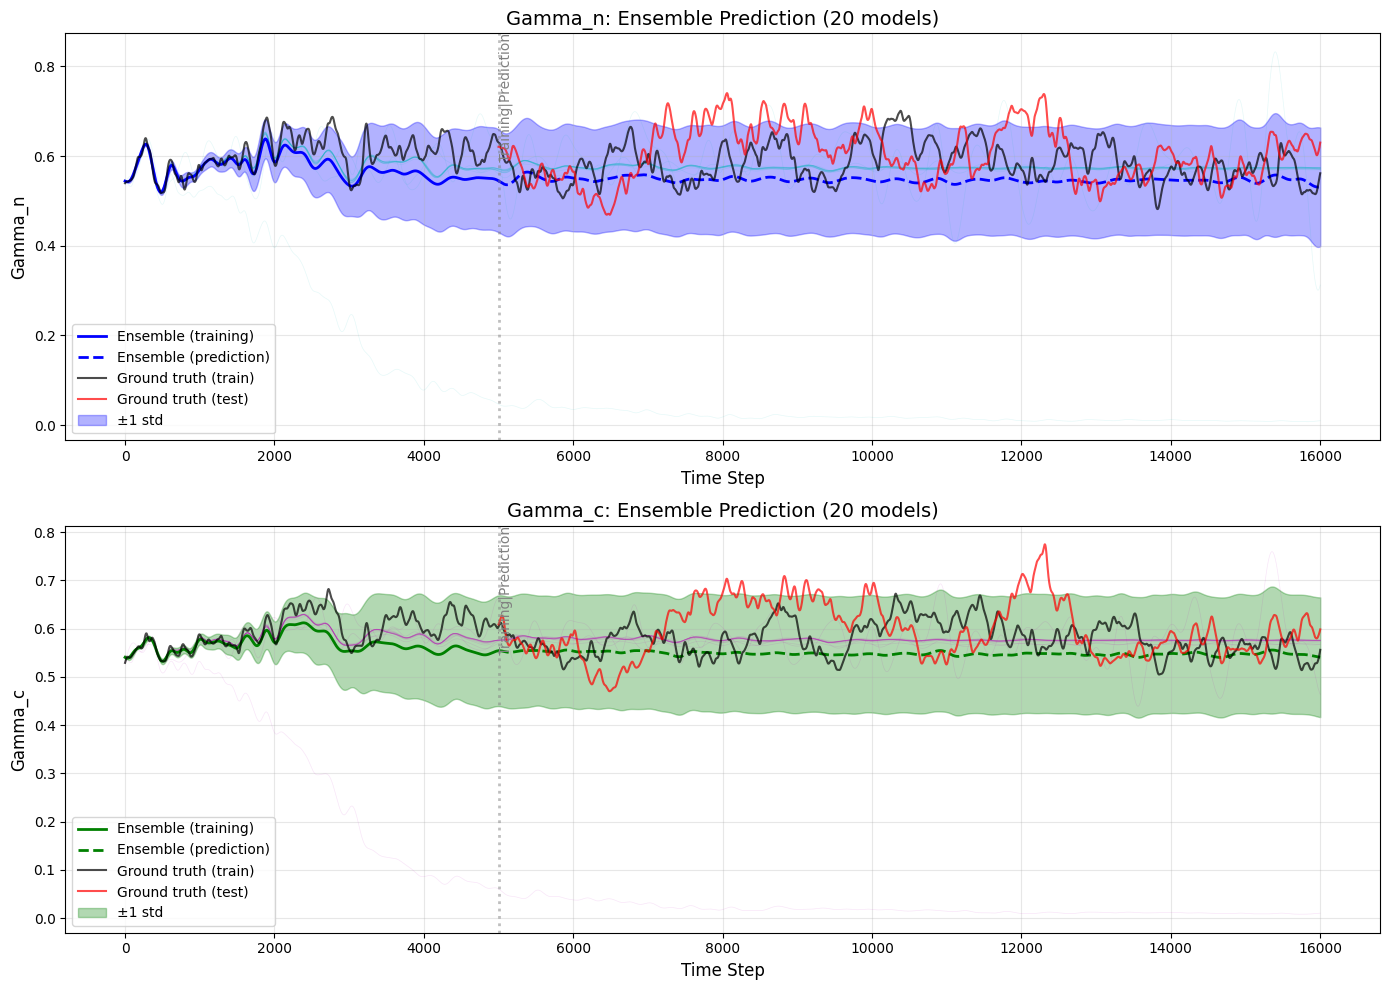


ENSEMBLE PREDICTION SUMMARY (r=100, k=20)

Prediction window: 16001 timesteps
Training portion: 5000 timesteps
Prediction portion: 11001 timesteps
Ground truth available: 11001 timesteps

Training portion (timesteps 0-5000):
  Gamma_n: mean=0.5705, std=0.0248
  Gamma_c: mean=0.5672, std=0.0180

Prediction portion (timesteps 5000-16001):
  Gamma_n: mean=0.5469, std=0.0052
  Gamma_c: mean=0.5485, std=0.0034

Ensemble uncertainty (avg std over prediction portion):
  Gamma_n: 0.122197
  Gamma_c: 0.121828

Prediction errors (MAE over 11001 timesteps):
  Gamma_n: 0.067183
  Gamma_c: 0.059051



In [ ]:
### Plot ensemble predictions vs ground truth for each trajectory
bprint("Creating ensemble prediction plots...")

# Compute ensemble statistics for each trajectory
def compute_ensemble_stats(predictions_list):
    """Compute mean and std across models for a list of trajectory predictions"""
    means = []
    stds = []
    for traj_preds in predictions_list:
        # traj_preds shape: (n_models, n_timesteps)
        means.append(np.mean(traj_preds, axis=0))
        stds.append(np.std(traj_preds, axis=0))
    return means, stds

train_Gamma_n_mean, train_Gamma_n_std = compute_ensemble_stats(train_predictions['Gamma_n'])
train_Gamma_c_mean, train_Gamma_c_std = compute_ensemble_stats(train_predictions['Gamma_c'])
test_Gamma_n_mean, test_Gamma_n_std = compute_ensemble_stats(test_predictions['Gamma_n'])
test_Gamma_c_mean, test_Gamma_c_std = compute_ensemble_stats(test_predictions['Gamma_c'])

###########################
# PLOT 1: Training Trajectories
###########################
fig, axes = plt.subplots(n_train_traj, 2, figsize=(16, 4*n_train_traj))
if n_train_traj == 1:
    axes = axes.reshape(1, -1)

for traj_idx in range(n_train_traj):
    time_steps = np.arange(len(train_Gamma_n_mean[traj_idx]))
    
    # Gamma_n
    ax = axes[traj_idx, 0]
    # Individual model predictions (faint)
    for model_idx in range(train_predictions['Gamma_n'][traj_idx].shape[0]):
        ax.plot(time_steps, train_predictions['Gamma_n'][traj_idx][model_idx, :], 
                'c-', alpha=0.1, linewidth=0.5)
    
    # Ensemble mean
    ax.plot(time_steps, train_Gamma_n_mean[traj_idx], 'b-', linewidth=2, label='Ensemble mean')
    
    # Uncertainty band
    ax.fill_between(time_steps,
                    train_Gamma_n_mean[traj_idx] - train_Gamma_n_std[traj_idx],
                    train_Gamma_n_mean[traj_idx] + train_Gamma_n_std[traj_idx],
                    alpha=0.3, color='blue', label='±1 std')
    
    # Ground truth
    ax.plot(time_steps, train_truth['Gamma_n'][traj_idx], 'k-', linewidth=1.5, 
            label='Ground truth', alpha=0.7)
    
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Gamma_n', fontsize=11)
    ax.set_title(f'Training Trajectory {traj_idx + 1}: Gamma_n', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Gamma_c
    ax = axes[traj_idx, 1]
    # Individual model predictions (faint)
    for model_idx in range(train_predictions['Gamma_c'][traj_idx].shape[0]):
        ax.plot(time_steps, train_predictions['Gamma_c'][traj_idx][model_idx, :], 
                'm-', alpha=0.1, linewidth=0.5)
    
    # Ensemble mean
    ax.plot(time_steps, train_Gamma_c_mean[traj_idx], 'g-', linewidth=2, label='Ensemble mean')
    
    # Uncertainty band
    ax.fill_between(time_steps,
                    train_Gamma_c_mean[traj_idx] - train_Gamma_c_std[traj_idx],
                    train_Gamma_c_mean[traj_idx] + train_Gamma_c_std[traj_idx],
                    alpha=0.3, color='green', label='±1 std')
    
    # Ground truth
    ax.plot(time_steps, train_truth['Gamma_c'][traj_idx], 'k-', linewidth=1.5, 
            label='Ground truth', alpha=0.7)
    
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Gamma_c', fontsize=11)
    ax.set_title(f'Training Trajectory {traj_idx + 1}: Gamma_c', fontsize=12)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path + f"ensemble_train_trajectories_r{r}_k{num_models_used}.png", 
            dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}ensemble_train_trajectories_r{r}_k{num_models_used}.png")
plt.show()

###########################
# PLOT 2: Test Trajectories
###########################
fig, axes = plt.subplots(n_test_traj, 2, figsize=(16, 4*n_test_traj))
if n_test_traj == 1:
    axes = axes.reshape(1, -1)

for traj_idx in range(n_test_traj):
    time_steps = np.arange(len(test_Gamma_n_mean[traj_idx]))
    
    # Gamma_n
    ax = axes[traj_idx, 0]
    # Individual model predictions (faint)
    for model_idx in range(test_predictions['Gamma_n'][traj_idx].shape[0]):
        ax.plot(time_steps, test_predictions['Gamma_n'][traj_idx][model_idx, :], 
                'c-', alpha=0.1, linewidth=0.5)
    
    # Ensemble mean
    ax.plot(time_steps, test_Gamma_n_mean[traj_idx], 'b-', linewidth=2, label='Ensemble mean')
    
    # Uncertainty band
    ax.fill_between(time_steps,
                    test_Gamma_n_mean[traj_idx] - test_Gamma_n_std[traj_idx],
                    test_Gamma_n_mean[traj_idx] + test_Gamma_n_std[traj_idx],
                    alpha=0.3, color='blue', label='±1 std')
    
    # Ground truth
    ax.plot(time_steps, test_truth['Gamma_n'][traj_idx], 'r-', linewidth=1.5, 
            label='Ground truth', alpha=0.7)
    
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Gamma_n', fontsize=11)
    ax.set_title(f'Test Trajectory {traj_idx + 1}: Gamma_n (UNSEEN IC)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Gamma_c
    ax = axes[traj_idx, 1]
    # Individual model predictions (faint)
    for model_idx in range(test_predictions['Gamma_c'][traj_idx].shape[0]):
        ax.plot(time_steps, test_predictions['Gamma_c'][traj_idx][model_idx, :], 
                'm-', alpha=0.1, linewidth=0.5)
    
    # Ensemble mean
    ax.plot(time_steps, test_Gamma_c_mean[traj_idx], 'g-', linewidth=2, label='Ensemble mean')
    
    # Uncertainty band
    ax.fill_between(time_steps,
                    test_Gamma_c_mean[traj_idx] - test_Gamma_c_std[traj_idx],
                    test_Gamma_c_mean[traj_idx] + test_Gamma_c_std[traj_idx],
                    alpha=0.3, color='green', label='±1 std')
    
    # Ground truth
    ax.plot(time_steps, test_truth['Gamma_c'][traj_idx], 'r-', linewidth=1.5, 
            label='Ground truth', alpha=0.7)
    
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Gamma_c', fontsize=11)
    ax.set_title(f'Test Trajectory {traj_idx + 1}: Gamma_c (UNSEEN IC)', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_path + f"ensemble_test_trajectories_r{r}_k{num_models_used}.png", 
            dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}ensemble_test_trajectories_r{r}_k{num_models_used}.png")
plt.show()

In [ ]:
### Compute quantitative error metrics
bprint("Computing error metrics...")

def compute_errors(pred_mean_list, truth_list, name=""):
    """Compute MAE and relative errors for a set of trajectories"""
    maes = []
    rel_errors = []
    
    for i, (pred, truth) in enumerate(zip(pred_mean_list, truth_list)):
        # Ensure same length
        min_len = min(len(pred), len(truth))
        pred = pred[:min_len]
        truth = truth[:min_len]
        
        mae = np.mean(np.abs(pred - truth))
        rel_error = mae / (np.mean(np.abs(truth)) + 1e-10)
        
        maes.append(mae)
        rel_errors.append(rel_error)
        
        print(f"  {name} Traj {i+1}: MAE={mae:.6f}, Rel Error={rel_error:.4%}")
    
    print(f"\n  {name} Average: MAE={np.mean(maes):.6f}, Rel Error={np.mean(rel_errors):.4%}")
    return maes, rel_errors

print("\n" + "="*60)
print("TRAINING RECONSTRUCTION ERRORS")
print("="*60)
print("\nGamma_n:")
train_Gamma_n_maes, train_Gamma_n_rels = compute_errors(
    train_Gamma_n_mean, train_truth['Gamma_n'], "Train Gamma_n"
)

print("\nGamma_c:")
train_Gamma_c_maes, train_Gamma_c_rels = compute_errors(
    train_Gamma_c_mean, train_truth['Gamma_c'], "Train Gamma_c"
)

print("\n" + "="*60)
print("TEST PREDICTION ERRORS (UNSEEN ICs)")
print("="*60)
print("\nGamma_n:")
test_Gamma_n_maes, test_Gamma_n_rels = compute_errors(
    test_Gamma_n_mean, test_truth['Gamma_n'], "Test Gamma_n"
)

print("\nGamma_c:")
test_Gamma_c_maes, test_Gamma_c_rels = compute_errors(
    test_Gamma_c_mean, test_truth['Gamma_c'], "Test Gamma_c"
)

# Compute average uncertainty
print("\n" + "="*60)
print("ENSEMBLE UNCERTAINTY (Avg Std Dev)")
print("="*60)
for i in range(n_train_traj):
    print(f"  Train Traj {i+1}: Gamma_n std={np.mean(train_Gamma_n_std[i]):.6f}, "
          f"Gamma_c std={np.mean(train_Gamma_c_std[i]):.6f}")

for i in range(n_test_traj):
    print(f"  Test Traj {i+1}: Gamma_n std={np.mean(test_Gamma_n_std[i]):.6f}, "
          f"Gamma_c std={np.mean(test_Gamma_c_std[i]):.6f}")

print("="*60 + "\n")

# Save metrics
np.savez(
    output_path + f"ensemble_metrics_r{r}_k{num_models_used}.npz",
    train_Gamma_n_maes=train_Gamma_n_maes,
    train_Gamma_n_rels=train_Gamma_n_rels,
    train_Gamma_c_maes=train_Gamma_c_maes,
    train_Gamma_c_rels=train_Gamma_c_rels,
    test_Gamma_n_maes=test_Gamma_n_maes,
    test_Gamma_n_rels=test_Gamma_n_rels,
    test_Gamma_c_maes=test_Gamma_c_maes,
    test_Gamma_c_rels=test_Gamma_c_rels
)
print(f"Metrics saved to: {output_path}ensemble_metrics_r{r}_k{num_models_used}.npz")